# Instacart Market Basket Analysis

This project involves conducting an exploratory data analysis (EDA) on Instacart transactions. Instacart is a grocery delivery platform where customers can place a grocery order and have it delivered to them. The dataset includes five tables:<br><br>1. orders: each row corresponds to one Instacart order<br>2. products: each rows corresponds to a unique product available for purchase<br>3. departments: each row corresponds to a unique grocery department category<br>4. aisles: each row corresponds to a unique grocery aisle category<br>5. order_products: each row corresponds to one item placed in an order<br><br>The objectives of this EDA are to clean up the dataset, analyze the transaction data to uncover customer shopping patterns and behaviors, and prepare a report on Instacart customer shopping habits with visualizations.

## Importing required libraries

The first step is to import the libraries needed for the analysis and load the five tables in the dataset. The csv files are delimited using ';' so we need to set sep=';' to read the data correctly. 

In [ ]:
# Import libraries 
import pandas as pd
import matplotlib.pyplot as plt

In [225]:
# Load the datasets
# Note: These files use semicolon (;) as the separator instead of comma
orders         = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products       = pd.read_csv('/datasets/products.csv', sep=';')
departments    = pd.read_csv('/datasets/departments.csv', sep=';')
aisles         = pd.read_csv('/datasets/aisles.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

## Initial look at data

 Next, calling .info() and .head() gives a sense of what the values in the dataset look like, confirms the data types and identifies the columns in each table that have missing values. 

In [ ]:
# Look at orders
orders

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478962,3210681,5617,5,1,14,7.0
478963,3270802,112087,2,3,13,6.0
478964,885349,82944,16,2,11,6.0
478965,216274,4391,3,3,8,8.0


In [ ]:
# Look at products
products

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


I repeat this process for each dataset to understand the structure, including the types of columns and rows they contain.

In [ ]:
# Look at departments
departments

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [229]:
# In this cell, type "aisles" below this line and execute the cell
aisles

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation
...,...,...
129,130,hot cereal pancake mixes
130,131,dry pasta
131,132,beauty
132,133,muscles joints pain relief


In [ ]:
# Look at order_products
order_products

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1
...,...,...,...,...
4545002,577211,15290,12.0,1
4545003,1219554,21914,9.0,0
4545004,692640,47766,4.0,1
4545005,319435,691,8.0,1


In [ ]:
# Call info on orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


The "Non-Null Count" column provides information about any missing values in each column of the dataset. With a total of 478,952 entries, I'll observe any columns where the non-null count is less than this number to identify missing values.

In [ ]:
# Call info on order_products
order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [ ]:
# Call info on products
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [ ]:
# Call info on departments
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [ ]:
# Call info on aisles
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


<b>Explanation of results</b><br><br>Of the five datasets, three have columns with missing values:<br><br>1. orders missing values in the days_since_prior_order column<br>2. order_products missing values in the add_to_cart_order column<br>3. products missing values in the product_name column

## Addressing missing values

Three tables have a column with missing values. In this next step, we take a closer look at the missing values, determine why they might be missing, and fill them in where possible so they don't throw off the analysis.

We will begin by addressing the missing values in the `products` data frame.

In [236]:
# Display rows where the product_name column has missing values
print(products[products['product_name'].isna()])


       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


It seems suspicious that all rows with missing `product_name` might be associated with `aisle_id` 100 and `department_id` 21. Let’s verify this by checking if any rows with missing `product_name` have an `aisle_id` different from 100 and 21. This will help us confirm if the issue is isolated to this aisle or spread across others.

In [237]:
# Combine conditions to check for missing product names in aisles other than 100
missing_products=products[products['product_name'].isna()]
missing_products_aisle=missing_products[~missing_products['aisle_id']==100]
print(missing_products_aisle)

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [238]:
# Combine conditions to check for missing product names in departments other than 21
missing_products_department=missing_products[~missing_products['department_id']==21]
print(missing_products_department)

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Confirmed: missing product names isolated to aisle 100, department 21

To better understand the missing product_name values, let’s determine what department_id 21 and aisle_id 100 represent by referencing the departments and aisles tables.

In [239]:
# What is this aisle and department?
department_21=departments.loc[departments['department_id']==21,'department'].iloc[0]
aisle_100=aisles.loc[aisles['aisle_id']==100,'aisle'].iloc[0]
print('department ID 21 represents:',department_21,'and aisle ID 100 represents:',aisle_100)

department ID 21 represents: missing and aisle ID 100 represents: missing


In [ ]:
# Fill missing product names with 'Unknown'
products['product_name'].fillna('Unknown',inplace=True)
# Print missing values to verify no missing values remain in the dataset
print(products[products['product_name'].isna()])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Now let's fill in missing values from the `orders` table.

In [241]:
# Display rows where the days_since_prior_order column has missing values
print(orders[orders['days_since_prior_order'].isna()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [242]:
# Are there any missing values where it's not a customer's first order?
missing_days=orders[orders['days_since_prior_order'].isna()]
missing_days_order_number=missing_days[~missing_days['order_number']==1]
print(missing_days_order_number)

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


All of the missing `'days_since_prior_order'` values correspond to a customer's first ever order. This makes sense because there is no prior order! We'll leave the values as `NaN` so the column can remain numeric. Also, the `NaN` values shouldn't interfere with any calculations we might do using this column.

Now let's fill in missing values from the order_products table.

In [243]:
# Display rows where the add_to_cart_order column has missing values
print(order_products[order_products['add_to_cart_order'].isna()])

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [244]:
# Use .min() and .max() to find the minimum and maximum values for this column.
print('minimum:',order_products['add_to_cart_order'].min(),'maximum:',order_products['add_to_cart_order'].max())

minimum: 1.0 maximum: 64.0


In [245]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
order_products_missing=order_products[order_products['add_to_cart_order'].isna()]
order_products_missing_ids=order_products_missing['order_id'].unique()
print(order_products_missing_ids)

[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [ ]:
# Do all orders with missing values have more than 64 products?
# Filter order_products for only the order ids with at least one missing value in 'add_to_cart_order'
orders_with_missing_values=order_products[order_products['order_id'].isin(order_products_missing_ids)][['order_id','product_id']]
# Use groupby to create a series of product counts for each order id with missing values
orders_missing_product_count=orders_with_missing_values.groupby('order_id')['product_id'].count()
print(orders_missing_product_count.head())
# Filter the series to check for any orders with missing values that have 64 products or less
filtered_product_count=orders_missing_product_count[orders_missing_product_count<=64]
print()
print("orders with missing values that have 64 products or less:",filtered_product_count)

order_id
9310       65
61355     127
102236     95
129627     69
165801     70
Name: product_id, dtype: int64

orders with missing values that have 64 products or less: Series([], Name: product_id, dtype: int64)


Confirmed: all orders with missing values have more than 64 products

In [ ]:
# Replace missing values with 999 and convert column to integer type
order_products['add_to_cart_order'].fillna(999,inplace=True)
# Print missing values to verify no missing values remain in the dataset
print(order_products[order_products['add_to_cart_order'].isna()])

import numpy as np
# Make sure shape and elements will be same after converting column to integer type
np.array_equal(order_products['add_to_cart_order'],order_products['add_to_cart_order'].astype('int'))
# Convert column to integer type
order_products['add_to_cart_order']=order_products['add_to_cart_order'].astype('int')
# Confirm data type of column
order_products['add_to_cart_order'].dtype

Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


dtype('int64')

For some reason, any item placed in the cart 65th or later has a missing value in the `'add_to_cart_order'` column. Maybe the data type of that column in the database could only hold integer values from 1 to 64. We've decided to replace the missing values with a code value, 999, that represents an unknown placed in cart order above 64. We also converted the column to integer data type. We just need to be careful to remember this if we perform calculations using this column during our analysis.

Other sensible code values we could've used are 0 or -1 because they don't show up elsewhere in the dataset and they don't have any real physical meaning for this variable.

Also note that, for orders with exactly 65 items, we could replace the missing value with 65. But we're going to neglect that for now since we can't determine the 65th item for all orders with 66 items or more.

## Finding and removing duplicate values

Each dataset may contain duplicate rows, which can lead to redundancy and affect the accuracy of our analysis. To handle this I will:

1. Use the `.duplicated()` method to identify duplicate rows. This method returns a Boolean series where `True` indicates a duplicate row.
2. Apply the `.drop_duplicates()` method to remove these duplicate rows, ensuring a cleaner dataset.

I will repeat this process for all datasets to ensure they are free of duplicate rows.

### `orders` data frame

In [248]:
# Find the number of duplicate rows in the orders dataframe
print(orders.duplicated().sum())

15


In [249]:
# View the duplicate rows
print(orders[orders.duplicated()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

In [250]:
# Remove duplicate orders
orders.drop_duplicates().reset_index(drop=True)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478947,3210681,5617,5,1,14,7.0
478948,3270802,112087,2,3,13,6.0
478949,885349,82944,16,2,11,6.0
478950,216274,4391,3,3,8,8.0


In [251]:
# Double check for duplicate rows
print(orders.duplicated().sum())

15


### `products` data frame

In [252]:
# Check for fully duplicate rows
print(products.duplicated().sum())

0


In [253]:
# Check for just duplicate product IDs using subset='product_id' in duplicated()
print(products.duplicated(subset='product_id').sum())

0


In [254]:
# Check for just duplicate product names (convert names to lowercase to compare better)
products['product_name']=products['product_name'].str.lower()
print(products.duplicated(subset='product_name').sum())

1361


Let's see what that looks like in our dataset :

In [255]:
products[products['product_name'].str.lower() == 'high performance energy drink']

,product_id,product_name,aisle_id,department_id
22540,22541,high performance energy drink,64,7
49689,49690,high performance energy drink,64,7


In [256]:
# Drop duplicate product names (case insensitive)
products.drop_duplicates(subset='product_name').reset_index(drop=True)

,product_id,product_name,aisle_id,department_id
0,1,chocolate sandwich cookies,61,19
1,2,all-seasons salt,104,13
2,3,robust golden unsweetened oolong tea,94,7
3,4,smart ones classic favorites mini rigatoni wit...,38,1
4,5,green chile anytime sauce,5,13
...,...,...,...,...
48328,49684,vodka- triple distilled- twist of vanilla,124,5
48329,49685,en croute roast hazelnut cranberry,42,1
48330,49686,artisan baguette,112,3
48331,49687,smartblend healthy metabolism dry cat food,41,8


In [257]:
# Double check for duplicate product names
print(products.duplicated(subset='product_name').sum())

1361


### `departments` data frame

In [258]:
# Check for duplicate entries in the departments dataframe
print(departments.duplicated().sum())

0


### `aisles` data frame

In [259]:
# Check for duplicate entries in the aisles dataframe
print(aisles.duplicated().sum())

0


### `order_products` data frame

In [260]:
# Check for duplicate entries in the order_products dataframe
print(order_products.duplicated().sum())

0


We have now successfully cleaned our data. Let's begin our exploratory data analysis.

# EDA

Now that the dataset is clean, we begin exploring patterns in the data. First, we verify that the values are within expected ranges. Next, we look at patterns in customer behavior including shopping trends across hours of the day and days of the week and how long customers wait between orders.

### Verifying that the 'order_hour_of_day' and 'order_dow' values in the orders tables are sensible 

In [ ]:
# Extract distinct values from order_hour_of_day
order_hours=orders['order_hour_of_day'].unique()
# Print values in ascending order
print(sorted(order_hours))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


Confirmed: values range from 0 to 23

In [ ]:
# Extract distinct values from order_dow
order_dows=orders['order_dow'].unique()
# Print values in ascending order
print(sorted(order_dows))

[0, 1, 2, 3, 4, 5, 6]


Confirmed: values range from 0 to 6

### What time of day do people shop for groceries?

To determine the time of day people shop for groceries, I'll analyze the order_hour_of_day column in the orders dataset. 

Finally, I'll visualize the data with a bar plot to easily observe the shopping trends across different times of the day.

In [ ]:
# Count number of orders by hour
order_hours=orders['order_hour_of_day'].value_counts()
# Sort by hour
order_hours_sorted=order_hours.sort_index()
# Print result
print(order_hours_sorted)

0      3180
1      1763
2      1004
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64


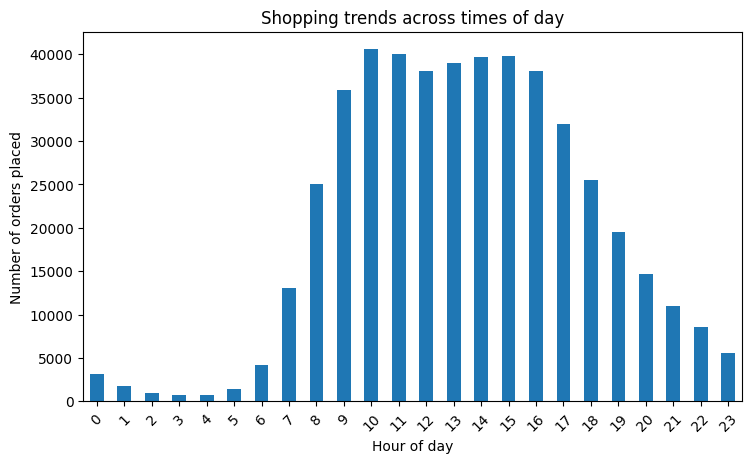

In [ ]:
# Plot series as a bar chart
order_hours_sorted.plot(kind='bar', xlabel='Hour of day', ylabel='Number of orders placed', legend=False,title='Shopping trends across times of day',rot=45,figsize=(8.5,4.8))

plt.show()

Most orders occur between 9:00 AM and 5:00 PM, with peaks at 10:00 AM and 3:00 PM

### What day of the week do people shop for groceries?

To figure out what day of the week people shop for groceries, I'll analyze the order_dow column in the orders dataset. Use .value_counts() to count the number of orders for each day of the week, and then sort the results by the day index to maintain the correct order.

I visualize the data with a bar plot to clearly observe shopping patterns across the days of the week.

In [ ]:
# Count number of orders by day of the week
order_days=orders['order_dow'].value_counts()
# Sort by day
order_days_sorted=order_days.sort_index()
# Print result
print(order_days_sorted)

0    84090
1    82185
2    65833
3    60912
4    59810
5    63488
6    62649
Name: order_dow, dtype: int64


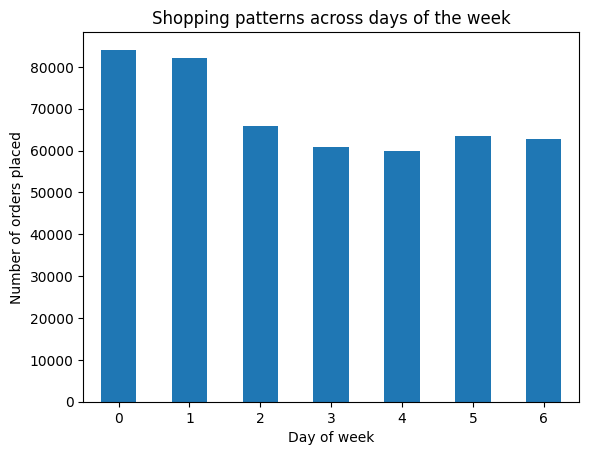

In [ ]:
# Plot series as a bar chart
order_days_sorted.plot(kind='bar', xlabel='Day of week', ylabel='Number of orders placed', legend=False,title='Shopping patterns across days of the week',rot=0)

plt.show()

The data dictionary does not state which integer corresponds to which day of the week. Assuming Sunday = 0, then people place more orders at the beginning of the week (Sunday and Monday).

### How long do people wait until placing another order?

To understand how long people wait before placing another order, I'll analyze the days_since_prior_order column in the orders dataset. Use .value_counts() to count how many orders were placed for each interval of days, then sort the results by the number of days for clarity.

I'll visualize the data using a bar plot to observe patterns in ordering frequency over time.

In [ ]:
# Count number of orders by interval of days
order_intervals=orders['days_since_prior_order'].value_counts()
# Sort by intervals
order_intervals_sorted=order_intervals.sort_index()
# Print result
print(order_intervals_sorted)

0.0      9589
1.0     20179
2.0     27141
3.0     30225
4.0     31007
5.0     30096
6.0     33931
7.0     44579
8.0     25361
9.0     16754
10.0    13310
11.0    11467
12.0    10658
13.0    11737
14.0    13992
15.0     9416
16.0     6588
17.0     5498
18.0     4972
19.0     4939
20.0     5302
21.0     6448
22.0     4514
23.0     3337
24.0     3015
25.0     2711
26.0     2640
27.0     2986
28.0     3745
29.0     2673
30.0    51338
Name: days_since_prior_order, dtype: int64


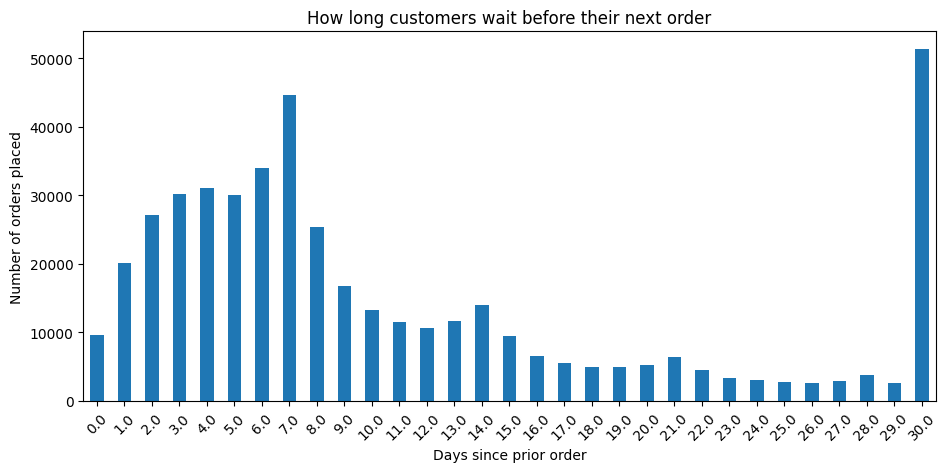

In [ ]:
# Plot series as a bar chart
order_intervals_sorted.plot(kind='bar', xlabel='Days since prior order', ylabel='Number of orders placed', legend=False,title='How long customers wait before their next order',rot=45,figsize=(11,4.8))

plt.show()

The 0 values probably correspond to customers who placed more than one order on the same day.

The max value of 30 days and the high spike at that value is puzzling, though. This spike might  be explained by people who set up recurring subscriptions to automatically order once a month. But that doesn't explain why there are no values above 30 days. I would expect many customers to place orders less often than once a month. Maybe those customers were intentionally excluded from the dataset.

Disregarding the spike at 30 days, most people wait between 2 to 10 days in between orders. The most common wait time is 7 days. In other words, it's common for people to place weekly grocery orders. Interestingly, in the tail of the distribution we also see small spikes at 14, 21, and 28 days. These would correspond to orders every 2, 3, or 4 weeks.

## Further Analysis
Digging further into our analysis, we examine order patterns over hours of the day between Wednesday and Saturday, the distribution of order totals per customer, and the 20 most popular products ordered. 

### Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays?

To determine if there’s a difference in the `order_hour_of_day` distributions on Wednesdays and Saturdays, I will:

1. **Create masks** for Wednesday (`order_dow == 3`) and Saturday (`order_dow == 6`) to filter the orders data.
2. **Count the order hours** for each day using `.value_counts()` and sort them by hour with `.sort_index()` for clarity.
3. **Combine the counts** for both days into a single DataFrame using `pd.concat()`, and label the columns for easier interpretation.

After preparing the data, I'll plot histograms for both days to visually compare the distribution of order times.


In [ ]:
# Create masks for wednesday and saturday
weds_mask=orders[orders['order_dow']==3]
sat_mask=orders[orders['order_dow']==6]

# Print result
print(weds_mask.head())
print(sat_mask.head())

    order_id  user_id  order_number  order_dow  order_hour_of_day  \
6    2511640   148233            40          3                  8   
16   3109465    55090            19          3                 15   
28    133707   182261             1          3                 10   
30   1890318   193501             3          3                 15   
35    125325   106853             6          3                 19   

    days_since_prior_order  
6                      2.0  
16                     9.0  
28                     NaN  
30                    30.0  
35                    30.0  
    order_id  user_id  order_number  order_dow  order_hour_of_day  \
0    1515936   183418            11          6                 13   
11    102585   191558            18          6                 16   
14   2843219    74699             4          6                 11   
20     50934   178510             9          6                  9   
26   1844247   122558             4          6                 18 

In [ ]:
# Count order hours for wednesday and saturday
weds_orders=weds_mask['order_hour_of_day'].value_counts()
sat_orders=sat_mask['order_hour_of_day'].value_counts()
# Sort by hour
weds_orders_sorted=weds_orders.sort_index()
sat_orders_sorted=sat_orders.sort_index()

# Print result
print(weds_orders_sorted)
print(sat_orders_sorted)

0      373
1      215
2      121
3      101
4      108
5      170
6      643
7     1732
8     3125
9     4490
10    5026
11    5004
12    4688
13    4674
14    4774
15    5163
16    4976
17    4175
18    3463
19    2652
20    1917
21    1450
22    1154
23     718
Name: order_hour_of_day, dtype: int64
0      464
1      254
2      177
3      125
4      118
5      161
6      451
7     1619
8     3246
9     4311
10    4919
11    5116
12    5132
13    5323
14    5375
15    5188
16    5029
17    4295
18    3338
19    2610
20    1847
21    1473
22    1185
23     893
Name: order_hour_of_day, dtype: int64


In [ ]:
# Combine counts for both days
weds_sat_concat=pd.concat([weds_orders_sorted,sat_orders_sorted], axis='columns')
# Name columns
weds_sat_concat.columns=['weds_orders','sat_orders']
print(weds_sat_concat)

    weds_orders  sat_orders
0           373         464
1           215         254
2           121         177
3           101         125
4           108         118
5           170         161
6           643         451
7          1732        1619
8          3125        3246
9          4490        4311
10         5026        4919
11         5004        5116
12         4688        5132
13         4674        5323
14         4774        5375
15         5163        5188
16         4976        5029
17         4175        4295
18         3463        3338
19         2652        2610
20         1917        1847
21         1450        1473
22         1154        1185
23          718         893


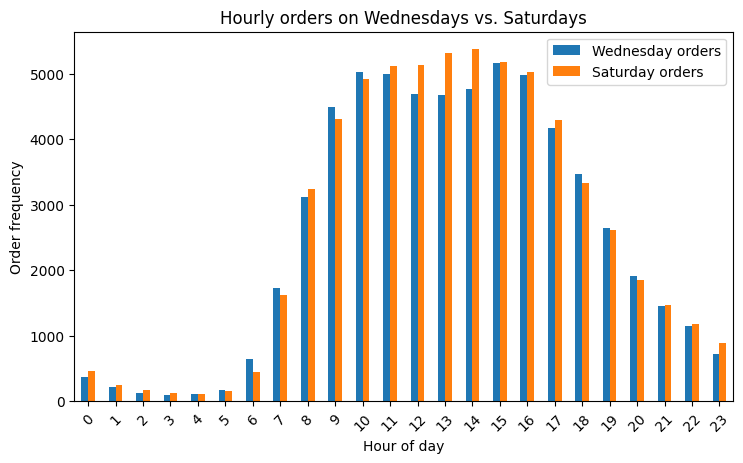

In [ ]:
# Plot dataframe to visually compare distribution
weds_sat_plot=weds_sat_concat.plot(kind='bar', xlabel='Hour of day', ylabel='Order frequency',title='Hourly orders on Wednesdays vs. Saturdays',rot=45,figsize=(8.5,4.8))

weds_sat_plot.legend(['Wednesday orders','Saturday orders'])
plt.show()

There's a small dip between 11h and 14h on Wednesdays. This dip is absent on Saturdays. Maybe this dip can be attributed to people who don't use Instacart because they have lunch somewhere between 11h and 13h.

### What's the distribution for the number of orders per customer?

To explore the distribution of the number of orders per customer, I will:

1. **Group the data** by `user_id` to calculate the total number of orders for each customer. Use `.groupby('user_id')` and count the `order_id` for each group.
2. **Sort the results** using `.sort_values()` for better readability.
3. **Visualize the distribution** using a histogram to observe how many orders most customers typically place.

I'll adjust the number of bins in the histogram to refine the visualization and better capture the pattern.

In [ ]:
# Group data by user_id and counting orders for each
customer_orders=orders.groupby('user_id')['order_id'].count()
# Sort data
customer_orders_sorted=customer_orders.sort_values()
print(customer_orders_sorted)

user_id
48965      1
139884     1
139876     1
60408      1
139873     1
          ..
66664     24
148162    24
78375     25
193164    26
149605    28
Name: order_id, Length: 157437, dtype: int64


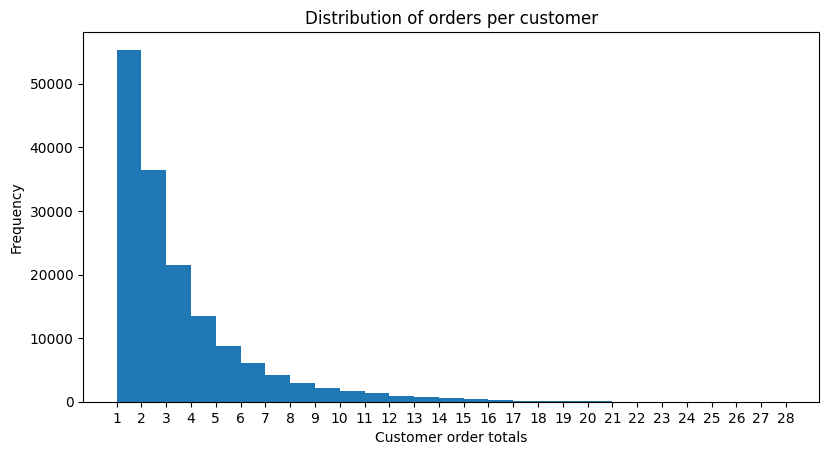

In [ ]:
# Plot histogram
customer_orders_sorted.plot(kind='hist',title='Distribution of orders per customer',bins=range(1,29,1),figsize=(9.5,4.8))

plt.xlabel('Customer order totals')
plt.xticks(range(1, 29, 1)) 

plt.show()

Most customers in the dataset have placed between 1 and 10 orders, with number of orders per customer sharply decreasing after just 1 order.

### What are the top 20 popular products (display their id and name)?

To identify the top 20 most popular products, I will:

1. **Merge the datasets**: Combine `order_products` and `products` on `product_id` to access both the product IDs and names in a single DataFrame.
2. **Group the data**: Group by both `product_id` and `product_name` to aggregate the order counts for each product using `.size()`.
3. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their popularity.
4. **Display the top 20**: Use `.head(20)` to focus on the most frequently ordered products.
5. **Visualize the results**: Create a bar chart to highlight the top products and their order counts.

This will give a clear view of the most popular products and their ranking.


In [ ]:
# Merge datasets using inside merge
merged_products=order_products.merge(products, on='product_id')
print(merged_products.head())

   order_id  product_id  add_to_cart_order  reordered  \
0   2141543       11440                 17          0   
1    147172       11440                  7          1   
2   3341719       11440                  4          1   
3   1938779       11440                  8          1   
4   1728338       11440                 23          0   

                     product_name  aisle_id  department_id  
0  chicken breast tenders breaded       129              1  
1  chicken breast tenders breaded       129              1  
2  chicken breast tenders breaded       129              1  
3  chicken breast tenders breaded       129              1  
4  chicken breast tenders breaded       129              1  


In [ ]:
# Group by product_name and product_id
merged_products_counts=merged_products.groupby(['product_id', 'product_name']).size()
print(merged_products_counts)

product_id  product_name                                                     
1           chocolate sandwich cookies                                           280
2           all-seasons salt                                                      11
3           robust golden unsweetened oolong tea                                  42
4           smart ones classic favorites mini rigatoni with vodka cream sauce     49
7           pure coconut water with orange                                         2
                                                                                ... 
49690       high performance energy drink                                          5
49691       original pancake & waffle mix                                         72
49692       organic instant oatmeal light maple brown sugar                       12
49693       spring water body wash                                                25
49694       burrito- steak & cheese                                     

In [ ]:
# Sort by most ordered products first and convert to dataframe to be able to plot just product names on x axis
merged_products_counts_sorted=merged_products_counts.sort_values(ascending=False).reset_index(name='order_count')
# Print top 20 rows
print(merged_products_counts_sorted.head(20))

    product_id              product_name  order_count
0        24852                    banana        66050
1        13176    bag of organic bananas        53297
2        21137      organic strawberries        37039
3        21903      organic baby spinach        33971
4        47209      organic hass avocado        29773
5        47766           organic avocado        24689
6        47626               large lemon        21495
7        16797              strawberries        20018
8        26209                     limes        19690
9        27845        organic whole milk        19600
10       27966       organic raspberries        19197
11       22935      organic yellow onion        15898
12       24964            organic garlic        15292
13       45007          organic zucchini        14584
14       39275       organic blueberries        13879
15       49683            cucumber kirby        13675
16       28204        organic fuji apple        12544
17        5876             o

The top 20 items are all produce, except for the milk. Looks like people want delicious and nutritious!

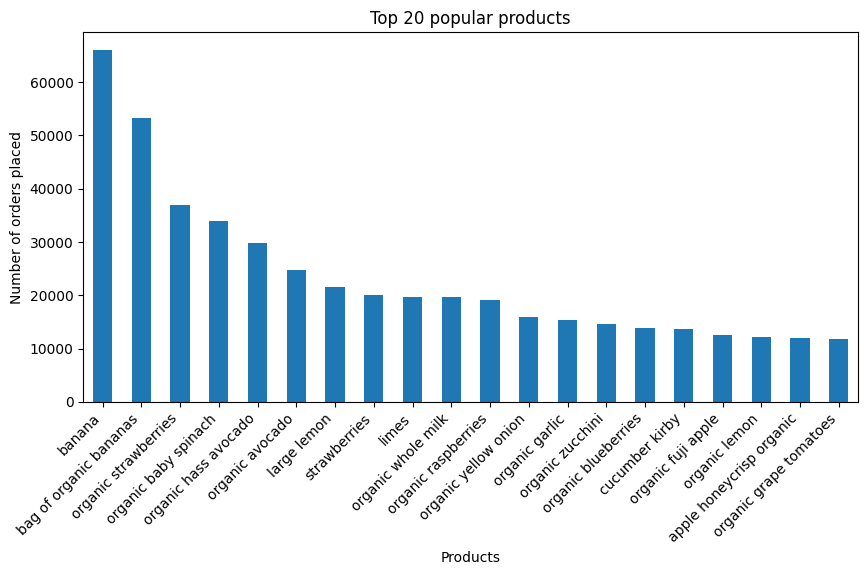

In [ ]:
# Plot top 20 products
merged_products_counts_sorted.head(20).plot(kind='bar', x='product_name', y='order_count', xlabel='Products', ylabel='Number of orders placed',title='Top 20 popular products', legend=False, rot=45,figsize=(10,4.8))
# Adjust alignment of labels on x axis to line up with ticks correctly (rotated for readability)
plt.xticks(ha='right')
plt.show()

Bananas (both organic and non-organic) are by far the most popular items, ordered twice as much as most other top items.

Finally, we examine the distribution of order sizes, the most reordered products, and the customers that tend to reorder the same products each time they shop.

### How many items do people typically buy in one order? What does the distribution look like?
To analyze how many items people typically buy in one order, I will:

1. **Group the data** by `order_id` and count the number of products (`product_id`) in each order using `.count()`. This gives the number of items in each order.
2. **Aggregate the counts**: Use `.value_counts()` to determine how frequently different order sizes occur, and then sort the results with `.sort_index()` to organize by the number of items.
3. **Visualize the distribution**: Use a bar plot to show the frequency of orders for each size, with the x-axis representing the number of items and the y-axis representing the number of orders.

This will help understand the typical size of a grocery order and identify any trends in purchasing behavior.

In [ ]:
# Group data to show number of items in each order
order_counts=order_products.groupby('order_id')['product_id'].count()
print(order_counts)

order_id
4          13
9          15
11          5
19          3
20          8
           ..
3421034    17
3421053     9
3421071     5
3421077     4
3421079     1
Name: product_id, Length: 450046, dtype: int64


In [ ]:
# Aggregate counts and sort by product count
order_size_frequency=order_counts.value_counts().sort_index()
print(order_size_frequency)

1      21847
2      26292
3      29046
4      31054
5      31923
       ...  
98         1
104        1
108        1
115        1
127        1
Name: product_id, Length: 90, dtype: int64


Most of the order numbers are in the tail of the distribution. To get a better look at the non-tail part, let's choose a value in the tail as a cutoff and just plot order with fewer than that many items. An order size of 35 items is far enough into the tail for this.

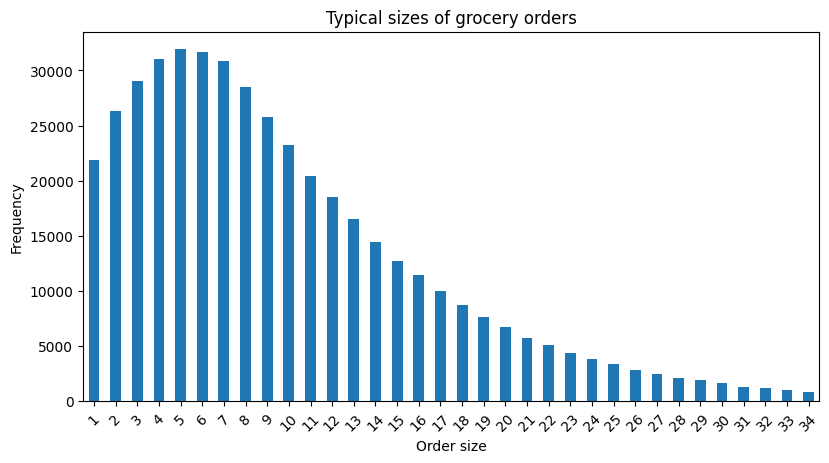

In [ ]:
# Plot order sizes with fewer than 35 items
order_size_frequency.head(34).plot(kind='bar',xlabel='Order size', ylabel='Frequency',title='Typical sizes of grocery orders', legend=False,rot=45,figsize=(9.5,4.8))
plt.show()

The typical order contains 5 or 6 items, with most orders having between 1 and 20 items.

### What are the top 20 items that are reordered most frequently?

To find the top 20 most frequently reordered items, I will:

1. **Filter the data**: Use `order_products['reordered'] == 1` to isolate only the products that have been reordered.
2. **Merge the datasets**: Combine the filtered `order_products` with the `products` dataset on `product_id` to get both the product names and IDs.
3. **Group the data**: Group by both `product_id` and `product_name` to calculate how many times each product was reordered, using `.size()`.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank the products by reorder frequency.
5. **Display the top 20**: Use `.head(20)` to focus on the most frequently reordered products.
6. **Visualize the data**: Create a bar chart to showcase the top reordered items and their frequencies.

This process highlights the products that customers consistently return to and reorder.

In [ ]:
# Filter dataframe for reordered products only
reordered_products=order_products[order_products['reordered'] == 1]
print(reordered_products.head())

   order_id  product_id  add_to_cart_order  reordered
1    567889        1560                  1          1
2   2261212       26683                  1          1
3    491251        8670                 35          1
4   2571142        1940                  5          1
5   2456893       21616                  4          1


In [ ]:
# Merge datasets using left merge
merged_reordered_products=reordered_products.merge(products,on='product_id',how='left')
print(merged_reordered_products.head())

   order_id  product_id  add_to_cart_order  reordered  \
0    567889        1560                  1          1   
1   2261212       26683                  1          1   
2    491251        8670                 35          1   
3   2571142        1940                  5          1   
4   2456893       21616                  4          1   

                                        product_name  aisle_id  department_id  
0                                         bag of ice        37              1  
1  cafe latte pure lightly sweetened iced coffee ...        91             16  
2                                     diced tomatoes        81             15  
3                        organic 2% reduced fat milk        84             16  
4                               organic baby arugula       123              4  


In [ ]:
# Group by product_id and product_name 
reorder_counts=merged_reordered_products.groupby(['product_name', 'product_id']).size().sort_values(ascending=False)
# Print top 20 most reordered products 
print(reorder_counts.head(20))

product_name              product_id
banana                    24852         55763
bag of organic bananas    13176         44450
organic strawberries      21137         28639
organic baby spinach      21903         26233
organic hass avocado      47209         23629
organic avocado           47766         18743
organic whole milk        27845         16251
large lemon               47626         15044
organic raspberries       27966         14748
strawberries              16797         13945
limes                     26209         13327
organic yellow onion      22935         11145
organic garlic            24964         10411
organic zucchini          45007         10076
cucumber kirby            49683          9538
organic fuji apple        28204          8989
apple honeycrisp organic  8277           8836
organic blueberries       39275          8799
organic lemon             5876           8412
organic half & half       49235          8389
dtype: int64


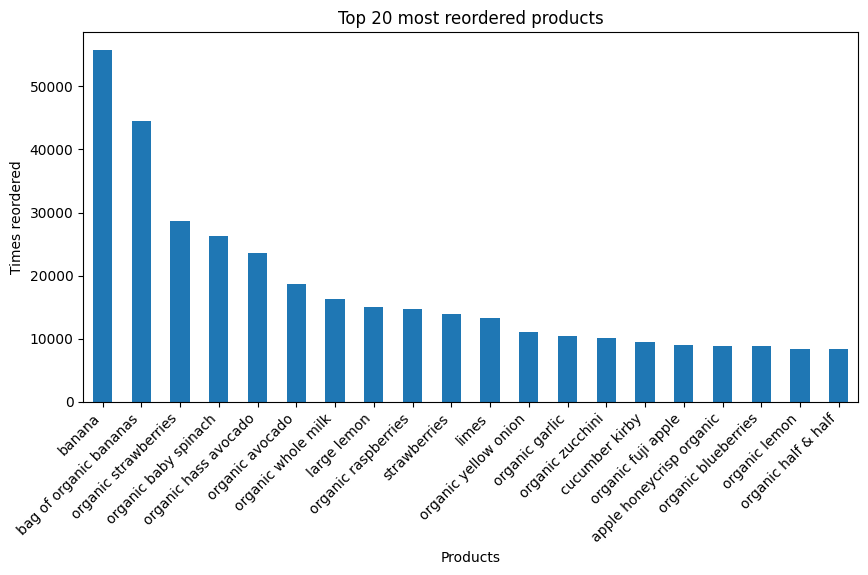

In [ ]:
# Convert to dataframe to show only product_name on x axis
reorder_counts=reorder_counts.reset_index(name='reorder_count')
# Plot in bar chart
reorder_counts.head(20).plot(kind='bar',x='product_name',y='reorder_count',xlabel='Products',ylabel='Times reordered',title='Top 20 most reordered products',legend=False,rot=45,figsize=(10,4.8))
# Adjust alignment of labels on x axis to line up with ticks correctly (rotated for readability)
plt.xticks(ha='right')
plt.show()

It looks like produce and dairy comprise the most reordered products as well. It makes sense that perishables would be the most reordered items.

### For each product, what proportion of its orders are reorders?

To calculate the proportion of orders for each product that are reorders, I will:

1. **Merge the datasets**: Combine `order_products` with the `products` dataset to access product names and IDs in the same DataFrame.
2. **Group the data**: Group by `product_id` and `product_name` to isolate each product's order history.
3. **Calculate the mean of `reordered`**: Use `.mean()` on the `reordered` column to compute the proportion of orders for each product that were reorders. The value represents the reorder rate.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their reorder rates.
5. **Convert to a DataFrame**: Use `.reset_index()` to organize the grouped data into a readable DataFrame.
6. **Optional Sorting**: Sort the results by `product_id` or another column for better clarity.

This approach provides insights into how frequently each product is reordered, helping identify customer favorites or staples.


In [ ]:
# Merge datasets using left merge
order_products_names=order_products.merge(products,on='product_id',how='left')
print(order_products_names.head())

   order_id  product_id  add_to_cart_order  reordered  \
0   2141543       11440                 17          0   
1    567889        1560                  1          1   
2   2261212       26683                  1          1   
3    491251        8670                 35          1   
4   2571142        1940                  5          1   

                                        product_name  aisle_id  department_id  
0                     chicken breast tenders breaded       129              1  
1                                         bag of ice        37              1  
2  cafe latte pure lightly sweetened iced coffee ...        91             16  
3                                     diced tomatoes        81             15  
4                        organic 2% reduced fat milk        84             16  


In [ ]:
# Group data by both product_id and product_name and compute reorder rates
product_reorder_rates=order_products_names.groupby(['product_id','product_name'])['reordered'].mean()
print(product_reorder_rates)

product_id  product_name                                                     
1           chocolate sandwich cookies                                           0.564286
2           all-seasons salt                                                     0.000000
3           robust golden unsweetened oolong tea                                 0.738095
4           smart ones classic favorites mini rigatoni with vodka cream sauce    0.510204
7           pure coconut water with orange                                       0.500000
                                                                                   ...   
49690       high performance energy drink                                        0.800000
49691       original pancake & waffle mix                                        0.430556
49692       organic instant oatmeal light maple brown sugar                      0.416667
49693       spring water body wash                                               0.440000
49694       burrito- s

In [ ]:
# Sort by highest reorder rate and convert to dataframe
top_reorder_rates=product_reorder_rates.sort_values(ascending=False).reset_index(name='reorder_rate')
top_reorder_rates_id=top_reorder_rates.sort_values(by=['reorder_rate','product_id'],ascending=[False,True])
# Print top 25 rows, displayed as strings to show full product names
print(top_reorder_rates_id.head(25).to_string())


      product_id                                                                product_name  reorder_rate
1030         154                                       corn dogs- mini- honey crunchy flavor           1.0
1384         173                               habanero lime shrimp flavor ramen noodle soup           1.0
1390         174                                              vanishing acne treatment cream           1.0
1295         193                                 fruitwater® strawberry kiwi sparkling water           1.0
1315         230                                                          vanilla cream soda           1.0
1275         337                                  soap- pure-castile- 18-in-1 hemp- lavender           1.0
1416         374                                                        sliced kosher salami           1.0
1408         414                                           gluten free chicken rustica pizza           1.0
1389         475                     

Dataframe shows customer favorites or staples at the top.

### For each customer, what proportion of their products ordered are reorders?

To calculate the proportion of products reordered by each customer, I will:

1. **Merge the datasets**: Combine `order_products` with `orders` to link order and customer information.
2. **Group the data**: Group by `user_id` to focus on each customer's ordering behavior.
3. **Calculate the mean of `reordered`**: Use `.mean()` on the `reordered` column to determine the proportion of products reordered by each customer.
4. **Sort the results**: Use `.sort_values(ascending=False)` to identify customers with the highest reorder rates.
5. **Convert to a DataFrame**: Use `.reset_index()` to format the grouped data into a structured DataFrame for further analysis.

This analysis reveals the extent to which individual customers reorder products, providing insights into customer loyalty and preferences.


In [ ]:
# Merge datasets using left merge
customer_orders=order_products.merge(orders,on='order_id',how='left')
print(customer_orders.head())
# Call .info to make sure user_id is filled in for all products
customer_orders.info(show_counts=True)

   order_id  product_id  add_to_cart_order  reordered  user_id  order_number  \
0   2141543       11440                 17          0    58454            25   
1    567889        1560                  1          1   129474            16   
2   2261212       26683                  1          1    47476             5   
3    491251        8670                 35          1   134505            27   
4   2571142        1940                  5          1   155995            22   

   order_dow  order_hour_of_day  days_since_prior_order  
0          0                 15                     8.0  
1          1                 13                    14.0  
2          6                  9                    13.0  
3          6                 13                     9.0  
4          5                 13                     5.0  
<class 'pandas.core.frame.DataFrame'>
Int64Index: 4545153 entries, 0 to 4545152
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype  
--- 

In [ ]:
# Group data by user id and compute reorder rates
customer_reorder_rates=customer_orders.groupby('user_id')['reordered'].mean()
print(customer_reorder_rates.sample(5))


user_id
42946     0.285714
84408     0.000000
105755    0.000000
84275     0.000000
135993    0.789474
Name: reordered, dtype: float64


In [ ]:
# Sort by highest reorder rate
customer_reorder_rates=customer_reorder_rates.sort_values(ascending=False)
# Convert to dataframe
customer_reorder_rates=customer_reorder_rates.reset_index(name='reorder_rate')
# Print top 25 rows
print(customer_reorder_rates.head(25))

    user_id  reorder_rate
0     96430           1.0
1     69003           1.0
2    199910           1.0
3    203290           1.0
4    140076           1.0
5     87731           1.0
6     69010           1.0
7    179451           1.0
8    197349           1.0
9    172208           1.0
10   140031           1.0
11   179450           1.0
12   184919           1.0
13    36588           1.0
14   140001           1.0
15   140000           1.0
16    25822           1.0
17    69059           1.0
18    45476           1.0
19    87734           1.0
20   172199           1.0
21    11929           1.0
22   110461           1.0
23    87784           1.0
24   140220           1.0


This dataframe identifies customers reordering most of their products (i.e., loyal "creatures of habit") at the top.

## Conclusion
This exploratory data analysis (EDA) on Instacart transactions yields a number of preliminary insights that can inform further analysis.<br><br> After identifying patterns in customer habits, it could be worth exploring any correlations between the observed patterns and existing app features. For example, are the peak ordering times of 10 AM and 3 PM correlated with the timing of app push notifications? Do the top ordered items correlate with the most suggested items in the app? <br><br> Depending on which features currently exist in the Instacart app, the EDA might also provide some insights to guide exploration for possible adjustments or even new features. For example, are push notifications currently tuned to reflect differences in peak ordering hours over different days of the week? Are product suggestions for loyal customers tuned to their individual order preferences? And, considering the large share of customers that drop off after placing one order, perhaps offering a coupon code could entice them to come back. <br><br>Overall, the patterns revealed in this analysis make intuitive sense and provide a strong foundation to dig deeper.